In [168]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

In [169]:
features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [170]:
# load churn models
#lgb_model = joblib.load("../models/churn_lgb_model.pkl")
#xgb_model = joblib.load("../models/churn_xgb_model.pkl")
churn_model = joblib.load("../models/churn_cat_model.pkl")
feature_cols = joblib.load("../models/feature_columns.pkl")

X = df[feature_cols]

In [171]:
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

p_return_train = churn_model.predict_proba(df_train[feature_cols])[:, 1]
p_return_val = churn_model.predict_proba(df_val[feature_cols])[:, 1]

df_return_train = df_train[df_train["revenue_2018_2019"] > 0].copy()
X_rev_train = df_return_train[feature_cols]
y_rev_train = np.log1p(df_return_train["revenue_2018_2019"])

# LightGBM

In [172]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_rev_train, y_rev_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4951
[LightGBM] [Info] Number of data points in the train set: 34106, number of used features: 30
[LightGBM] [Info] Start training from score 4.900509


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [173]:
# predict (still in log space)
log_preds = lgb_model.predict(df_val[feature_cols])

# back-transform from log space
preds = np.expm1(log_preds)

# Combine with churning
combined_preds = preds * p_return_val

# evaluate against real revenue
lgb_mae = mean_absolute_error(df_val["revenue_2018_2019"], combined_preds)
lgb_corr, _ = spearmanr(df_val["revenue_2018_2019"], combined_preds)

print(f"LightGBM - MAE: {lgb_mae:.2f}  Spearman: {lgb_corr:.4f}")


LightGBM - MAE: 72.20  Spearman: 0.3932


# XGBoost

In [174]:
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mae",
    random_state=42
)

xgb_model.fit(X_rev_train, y_rev_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [175]:
# predict (still in log space)
log_preds = xgb_model.predict(df_val[feature_cols])

# back-transform from log space
preds = np.expm1(log_preds)

# Combine with churning
combined_preds = preds * p_return_val

# evaluate against real revenue
xgb_mae = mean_absolute_error(df_val["revenue_2018_2019"], combined_preds)
xgb_corr, _ = spearmanr(df_val["revenue_2018_2019"], combined_preds)

print(f"XGBoost - MAE: {xgb_mae:.2f}  Spearman: {xgb_corr:.4f}")

XGBoost - MAE: 72.04  Spearman: 0.3952


# CatBoost

In [176]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    verbose=False,
    random_state=42
)

cat_model.fit(X_rev_train, y_rev_train)

CatBoostRegressor(depth=6, iterations=800, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=False)

In [177]:
# predict (still in log space)
log_preds = cat_model.predict(df_val[feature_cols])

# back-transform from log space
preds = np.expm1(log_preds)

# Combine with churning
combined_preds = preds * p_return_val

# evaluate against real revenue
cat_mae = mean_absolute_error(df_val["revenue_2018_2019"], combined_preds)
cat_corr, _ = spearmanr(df_val["revenue_2018_2019"], combined_preds)

print(f"CatBoost - MAE: {cat_mae:.2f}  Spearman: {cat_corr:.4f}")

CatBoost - MAE: 71.90  Spearman: 0.3971


# Comparison & Threshold Optimazation

In [ ]:
best_overall_mae = 1000
best_threshold = 0
rev_model = None
best_model_name = None

for name, model in [("LightGBM", lgb_model), ("XGBoost", xgb_model), ("CatBoost", cat_model)]:
    log_preds = model.predict(df_val[feature_cols])
    rev_preds = np.expm1(log_preds)
    
    best_corr, best_t, best_mae = -1, 0, 1000
    for t in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
        preds = np.where(p_return_val < t, 0, p_return_val * rev_preds)
        mae = mean_absolute_error(df_val["revenue_2018_2019"], preds)
        corr, _ = spearmanr(df_val["revenue_2018_2019"], preds)
        if mae < best_mae:
            best_corr, best_t, best_mae = corr, t, mae
    
    print(f"{name} - MAE: {best_mae:.2f}  Spearman: {best_corr:.4f}  Threshold: {best_t:.2f}")
    
    if best_mae < best_overall_mae:
        best_overall_mae = best_mae
        best_threshold = best_t
        rev_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name}  Threshold: {best_threshold:.2f}")

LightGBM - MAE: 62.76  Spearman: 0.3883  Threshold: 0.60
XGBoost - MAE: 62.68  Spearman: 0.3884  Threshold: 0.60
CatBoost - MAE: 62.60  Spearman: 0.3889  Threshold: 0.60

Best model: CatBoost  Threshold: 0.60


# incorporate churn probability threshold

In [179]:
p_return_all = churn_model.predict_proba(df[feature_cols])[:, 1]
rev_pred_all = np.expm1(rev_model.predict(df[feature_cols]))

final_pred = np.where(
    p_return_all < best_threshold, 
    0, 
    p_return_all * rev_pred_all)


In [180]:
mae_thresh = mean_absolute_error(df["revenue_2018_2019"], final_pred)

print("MAE:", mae_thresh)

corr_thresh,_ = spearmanr(df["revenue_2018_2019"], final_pred)

print("Spearman:", corr_thresh)

MAE: 61.22868421848188
Spearman: 0.4084917832597099


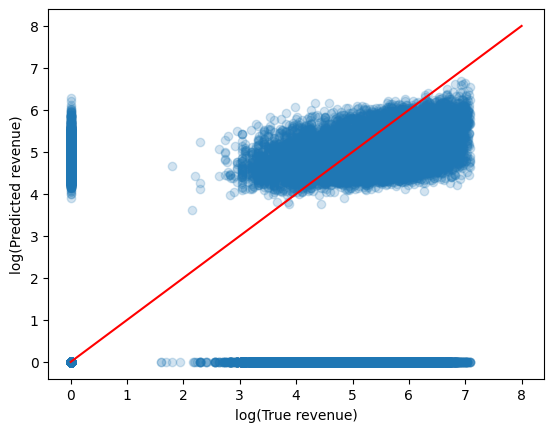

In [181]:
plt.scatter(
    np.log1p(df["revenue_2018_2019"]),
    np.log1p(final_pred),
    alpha=0.2
)

plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")

plt.plot([0,8],[0,8],"r")

plt.show()

# Save Revenue Model

In [182]:
joblib.dump(rev_model, "../models/rev_model.pkl")


['../models/rev_model.pkl']